<a href="https://colab.research.google.com/github/ivansuarez-AU/EGN-321-Module-5.1-Instructor-Demo/blob/main/EGN321_Module5_INSTRUCTOR_DEMO_Velxio_CSV_Upload_Ollama.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EGN 321 — Module 5 Instructor Demo
## Virtual Sensor Reliability + Ollama AI Review

This is the **instructor demonstration version** of the Assignment 5.1 Colab.

The notebook uses a **CSV uploaded from Velxio or Tinkercad** and follows this workflow:

**Virtual Sensor → Raw Evidence → Deterministic Validation → Filtering → Testing → Ollama Review → Verified Evidence**

### Instructor principle

> Python decides what the software accepts.  
> Ollama helps us **question, explain, review, and test** the rules.

The AI model is **not** the sensor, the validator, or the engineering authority.


## Instructor Demo Plan

A suggested classroom sequence:

1. **Show the Velxio sensor** and move the live control.
2. Copy several readings from the Serial Monitor.
3. Run the deterministic analysis first.
4. Ask students what looks wrong **before** using AI.
5. Start Ollama with the small `qwen2.5:0.5b` model.
6. Give Ollama the evidence summary and ask it to review the rule.
7. Convert one AI suggestion into an executable test.
8. Finish by asking what assumptions a typed-input tool made that the sensor broke.

**Do not begin with Ollama.** The class should first establish the evidence using Python.


## Working classroom rules

For this training example:

- `0 <= temperature <= 50` → `OK`
- `temperature > 50` → `OUT_OF_RANGE`
- `temperature < 0` → `MISSING`

These are **course/demo rules**, not universal sensor limits.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

pd.set_option("display.max_rows", 200)
print("Ready.")

Ready.


## Load Your Velxio CSV File

For the instructor demonstration, this notebook now asks you to **upload the CSV exported or created from your Velxio Serial Monitor data**.

### Expected data

The preferred CSV structure is:

```text
sample_number,temperature_c,status
1,20.4,OK
2,20.5,OK
3,80.0,OUT_OF_RANGE
4,-5.0,MISSING
```

The notebook also accepts:

```text
sample_number,temperature_c,simulator_status
```

If your Velxio output has **no header row**, the notebook will try to recognize the three-column format automatically.

> Upload one CSV file when the next cell prompts you.


In [2]:
import io
import pandas as pd

try:
    from google.colab import files
except ImportError:
    raise RuntimeError(
        "This upload cell is designed for Google Colab. "
        "Open the notebook in Colab and run the cell again."
    )

print("Please choose your Velxio CSV file.")
uploaded = files.upload()

if not uploaded:
    raise RuntimeError("No file was uploaded.")

csv_names = [
    name for name in uploaded.keys()
    if name.lower().endswith(".csv")
]

if len(csv_names) == 0:
    raise ValueError(
        "No CSV file was detected. Please upload a .csv file."
    )

if len(csv_names) > 1:
    print("Multiple CSV files were uploaded.")
    print("Using the first one:", csv_names[0])

uploaded_filename = csv_names[0]
csv_bytes = uploaded[uploaded_filename]

print("Uploaded:", uploaded_filename)

# ------------------------------------------------------------
# First attempt: read the file as a normal CSV with a header.
# ------------------------------------------------------------
df = pd.read_csv(io.BytesIO(csv_bytes))

# Normalize column names.
df.columns = [
    str(col).strip().lower().replace(" ", "_")
    for col in df.columns
]

# Accept either "status" or "simulator_status".
if "status" in df.columns and "simulator_status" not in df.columns:
    df = df.rename(columns={"status": "simulator_status"})

required = {"sample_number", "temperature_c", "simulator_status"}

# ------------------------------------------------------------
# Second attempt:
# If the required headers are missing, try headerless Velxio
# output with exactly three columns:
# sample_number, temperature_c, status
# ------------------------------------------------------------
if not required.issubset(df.columns):
    headerless = pd.read_csv(
        io.BytesIO(csv_bytes),
        header=None
    )

    if headerless.shape[1] != 3:
        raise ValueError(
            "The CSV does not match the expected three-column Velxio format.\n\n"
            "Expected:\n"
            "sample_number,temperature_c,status\n\n"
            "Example:\n"
            "1,20.4,OK"
        )

    headerless.columns = [
        "sample_number",
        "temperature_c",
        "simulator_status"
    ]
    df = headerless

# Keep only the fields needed by this lab.
df = df[
    ["sample_number", "temperature_c", "simulator_status"]
].copy()

# Clean values.
df["sample_number"] = pd.to_numeric(
    df["sample_number"],
    errors="coerce"
)

df["temperature_c"] = pd.to_numeric(
    df["temperature_c"],
    errors="coerce"
)

df["simulator_status"] = (
    df["simulator_status"]
    .astype(str)
    .str.strip()
    .str.upper()
)

# Remove completely unusable rows.
bad_rows = df[
    df["sample_number"].isna() |
    df["temperature_c"].isna()
]

if len(bad_rows):
    print(f"Warning: {len(bad_rows)} row(s) could not be parsed and will be removed.")
    display(bad_rows)

df = df.dropna(
    subset=["sample_number", "temperature_c"]
).copy()

df["sample_number"] = df["sample_number"].astype(int)
df["temperature_c"] = df["temperature_c"].astype(float)

df = df.sort_values("sample_number").reset_index(drop=True)

print(f"\nLoaded {len(df)} sensor readings.")
print("Columns:", list(df.columns))

display(df.head(12))


Please choose your Velxio CSV file.


Saving EGN321_Module5_Velxio_CSV_Format_Example.csv to EGN321_Module5_Velxio_CSV_Format_Example.csv
Uploaded: EGN321_Module5_Velxio_CSV_Format_Example.csv

Loaded 5 sensor readings.
Columns: ['sample_number', 'temperature_c', 'simulator_status']


,sample_number,temperature_c,simulator_status
0,1,20.4,OK
1,2,20.5,OK
2,3,49.2,OK
3,4,61.4,OUT_OF_RANGE
4,5,-5.0,MISSING


### Verify the Uploaded Dataset

Before continuing, confirm that the correct file was loaded and that it contains enough readings for Assignment 5.1.


In [3]:
# Quick verification before continuing the lab.

print("File:", uploaded_filename)
print("Readings:", len(df))
print("First sample:", df["sample_number"].min())
print("Last sample:", df["sample_number"].max())
print("\nSimulator status counts:")
display(df["simulator_status"].value_counts(dropna=False))

if len(df) < 100:
    print(
        "\nNOTE: Assignment 5.1 requires at least 100 readings. "
        f"This file currently contains {len(df)}."
    )
else:
    print("\nDataset meets the 100-reading minimum for Assignment 5.1.")


File: EGN321_Module5_Velxio_CSV_Format_Example.csv
Readings: 5
First sample: 1
Last sample: 5

Simulator status counts:


,count
simulator_status,
OK,3
OUT_OF_RANGE,1
MISSING,1



NOTE: Assignment 5.1 requires at least 100 readings. This file currently contains 5.


## 1. Basic data-quality checks


In [4]:
print("Rows:", len(df))
print("Duplicate sample numbers:", df["sample_number"].duplicated().sum())
print("Missing temperatures:", df["temperature_c"].isna().sum())
print("Status labels:", sorted(df["simulator_status"].unique()))

expected = set(range(df["sample_number"].min(), df["sample_number"].max()+1))
actual = set(df["sample_number"])
print("Missing sample numbers:", sorted(expected-actual) or "None")

Rows: 5
Duplicate sample numbers: 0
Missing temperatures: 0
Status labels: ['MISSING', 'OK', 'OUT_OF_RANGE']
Missing sample numbers: None


## 2. Recalculate the sensor status independently


In [5]:
def classify_temperature(value):
    if pd.isna(value):
        return "MISSING"
    if value < 0:
        return "MISSING"
    if value > 50:
        return "OUT_OF_RANGE"
    return "OK"

df["python_status"] = df["temperature_c"].apply(classify_temperature)
df["status_match"] = df["simulator_status"] == df["python_status"]

mismatches = df[~df["status_match"]]
print("Status mismatches:", len(mismatches))
display(mismatches if len(mismatches) else pd.DataFrame({"result":["All labels match the Python rule."]}))

Status mismatches: 0


,result
0,All labels match the Python rule.


## 3. Count each state


In [6]:
counts = df["python_status"].value_counts().rename_axis("status").reset_index(name="count")
counts["percent"] = (counts["count"]/len(df)*100).round(1)
display(counts)

,status,count,percent
0,OK,3,60.0
1,OUT_OF_RANGE,1,20.0
2,MISSING,1,20.0


## 4. Plot the raw readings


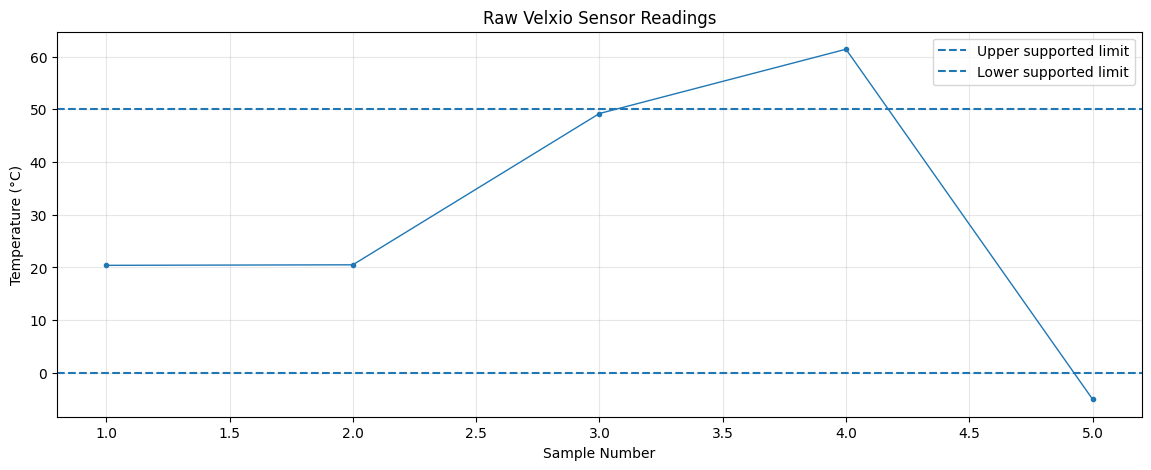

In [7]:
plt.figure(figsize=(14,5))
plt.plot(df["sample_number"], df["temperature_c"], marker=".", linewidth=1)
plt.axhline(50, linestyle="--", label="Upper supported limit")
plt.axhline(0, linestyle="--", label="Lower supported limit")
plt.xlabel("Sample Number")
plt.ylabel("Temperature (°C)")
plt.title("Raw Velxio Sensor Readings")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 5. Range and normal variation

Do not use invalid readings to describe normal variation.


In [8]:
valid_df = df[df["python_status"]=="OK"].copy()

summary = pd.DataFrame({
    "metric":[
        "Raw minimum","Raw maximum",
        "Valid minimum","Valid maximum",
        "Valid mean","Valid median",
        "Valid standard deviation",
        "Valid count"
    ],
    "value":[
        df["temperature_c"].min(),
        df["temperature_c"].max(),
        valid_df["temperature_c"].min(),
        valid_df["temperature_c"].max(),
        valid_df["temperature_c"].mean(),
        valid_df["temperature_c"].median(),
        valid_df["temperature_c"].std(),
        len(valid_df)
    ]
})
display(summary)

,metric,value
0,Raw minimum,-5.000000
1,Raw maximum,61.400000
2,Valid minimum,20.400000
3,Valid maximum,49.200000
4,Valid mean,30.033333
5,Valid median,20.500000
6,Valid standard deviation,16.598896
7,Valid count,3.000000


## 6. Look for suspicious jumps

A value can be inside the allowed range and still deserve investigation.

The threshold below is a **starting point for discussion**, not a universal rule.


In [9]:
JUMP_THRESHOLD_C = 15.0

df["previous_temperature"] = df["temperature_c"].shift(1)
df["absolute_change_c"] = (df["temperature_c"] - df["previous_temperature"]).abs()
df["large_jump"] = (
    (df["python_status"]=="OK") &
    (df["absolute_change_c"] > JUMP_THRESHOLD_C)
)

display(df[df["large_jump"]][[
    "sample_number","previous_temperature","temperature_c",
    "absolute_change_c","python_status"
]])

,sample_number,previous_temperature,temperature_c,absolute_change_c,python_status
2,3,20.5,49.2,28.7,OK


## 7. Preserve raw, accepted, and filtered values separately

- **raw_value** = exactly what the simulator produced
- **accepted_value** = passes validation
- **filtered_value** = smoothed accepted data


In [10]:
df["raw_value"] = df["temperature_c"]
df["accepted_value"] = np.where(df["python_status"]=="OK", df["temperature_c"], np.nan)

# 5-sample rolling median
df["filtered_value"] = (
    pd.Series(df["accepted_value"])
      .rolling(window=5, min_periods=1)
      .median()
)

display(df[[
    "sample_number","raw_value","simulator_status",
    "python_status","accepted_value","filtered_value"
]].head(45))

,sample_number,raw_value,simulator_status,python_status,accepted_value,filtered_value
0,1,20.4,OK,OK,20.4,20.40
1,2,20.5,OK,OK,20.5,20.45
2,3,49.2,OK,OK,49.2,20.50
3,4,61.4,OUT_OF_RANGE,OUT_OF_RANGE,NaN,20.50
4,5,-5.0,MISSING,MISSING,NaN,20.50


## 8. Compare raw and filtered data


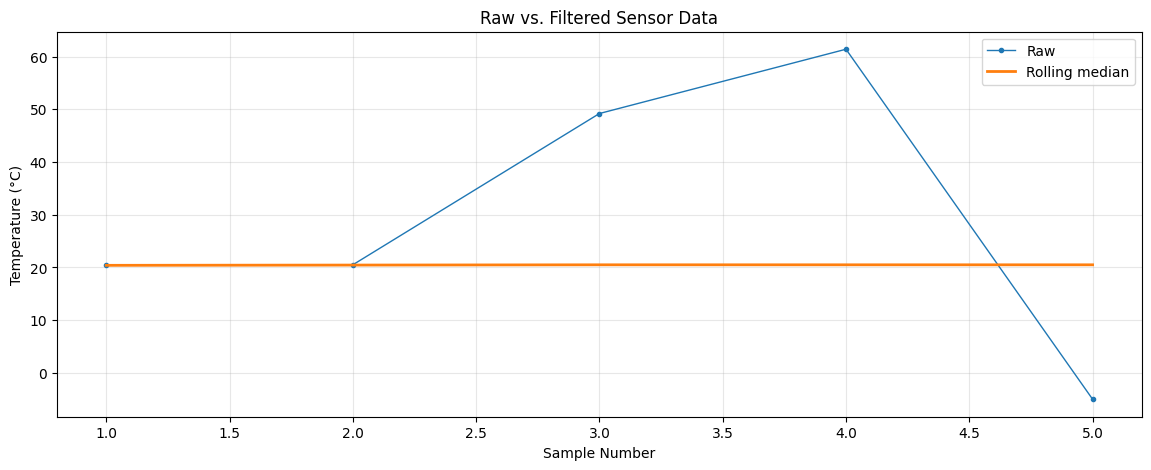

In [11]:
plt.figure(figsize=(14,5))
plt.plot(df["sample_number"], df["raw_value"], marker=".", linewidth=1, label="Raw")
plt.plot(df["sample_number"], df["filtered_value"], linewidth=2, label="Rolling median")
plt.xlabel("Sample Number")
plt.ylabel("Temperature (°C)")
plt.title("Raw vs. Filtered Sensor Data")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 9. Measure the cost of the rejection rule

The assignment asks not only **what you reject**, but **what that rule costs you**.


In [12]:
rejected = df[df["python_status"]!="OK"]
accepted = df[df["python_status"]=="OK"]

cost = pd.DataFrame({
    "measure":[
        "Total readings","Accepted readings","Rejected readings",
        "Missing readings","Out-of-range readings","Percent rejected"
    ],
    "value":[
        len(df), len(accepted), len(rejected),
        (df["python_status"]=="MISSING").sum(),
        (df["python_status"]=="OUT_OF_RANGE").sum(),
        round(len(rejected)/len(df)*100,1)
    ]
})
display(cost)

,measure,value
0,Total readings,5.0
1,Accepted readings,3.0
2,Rejected readings,2.0
3,Missing readings,1.0
4,Out-of-range readings,1.0
5,Percent rejected,40.0


## 10. Investigate repeated values

Long repeated runs may mean:
- a very stable environment,
- low sensor resolution,
- a frozen sensor,
- stale data,
- or simply that the simulator control was not moved.

They are not automatically failures.


In [13]:
def repeated_runs(series):
    values = series.tolist()
    runs = []
    start = 0
    for i in range(1, len(values)+1):
        if i == len(values) or values[i] != values[start]:
            runs.append({
                "value": values[start],
                "start_sample": start+1,
                "end_sample": i,
                "length": i-start
            })
            start = i
    return pd.DataFrame(runs)

runs = repeated_runs(df["temperature_c"])
display(runs[runs["length"]>=5].sort_values("length", ascending=False).head(20))

,value,start_sample,end_sample,length


## 11. Build your own rule

Change these thresholds only if you can justify them.


In [14]:
SUPPORTED_MIN = 0.0
SUPPORTED_MAX = 50.0
SUSPICIOUS_JUMP = 15.0

def student_sensor_rule(value, previous_accepted=None):
    if value is None or pd.isna(value):
        return "MISSING"
    if value < SUPPORTED_MIN:
        return "MISSING"
    if value > SUPPORTED_MAX:
        return "OUT_OF_RANGE"
    if previous_accepted is not None and not pd.isna(previous_accepted):
        if abs(value - previous_accepted) > SUSPICIOUS_JUMP:
            return "SUSPICIOUS"
    return "OK"

print("Rule ready.")

Rule ready.


## 12. Replay all readings through the rule


In [15]:
student_status = []
previous_accepted = None

for value in df["temperature_c"]:
    status = student_sensor_rule(value, previous_accepted)
    student_status.append(status)
    if status == "OK":
        previous_accepted = value

df["student_status"] = student_status

display(df[[
    "sample_number","temperature_c","python_status","student_status"
]].head(90))

print(df["student_status"].value_counts())

,sample_number,temperature_c,python_status,student_status
0,1,20.4,OK,OK
1,2,20.5,OK,OK
2,3,49.2,OK,SUSPICIOUS
3,4,61.4,OUT_OF_RANGE,OUT_OF_RANGE
4,5,-5.0,MISSING,MISSING


student_status
OK              2
SUSPICIOUS      1
OUT_OF_RANGE    1
MISSING         1
Name: count, dtype: int64


## 13. Test the rule


In [16]:
assert student_sensor_rule(20.4) == "OK"
assert student_sensor_rule(50.0) == "OK"
assert student_sensor_rule(50.1) == "OUT_OF_RANGE"
assert student_sensor_rule(-1.0) == "MISSING"
assert student_sensor_rule(np.nan) == "MISSING"
assert student_sensor_rule(40.0, previous_accepted=20.0) == "SUSPICIOUS"

print("All starter tests passed.")

All starter tests passed.


# Part 14 — Add Ollama as an AI Review Assistant

Now that the sensor rules have been tested deterministically, we can introduce a small local language model.

For this demonstration we will use:

**Ollama + `qwen2.5:0.5b`**

Why a small model?

- it is practical for a classroom Colab session;
- it starts faster than larger models;
- students can see that even a small model can help with explanation and test ideas;
- its suggestions still require verification.

### AI boundary for this lab

Ollama **may**:

- explain sensor concepts;
- review our reasoning;
- suggest edge cases;
- propose tests;
- identify assumptions;
- help explain failures.

Ollama **may not**:

- invent sensor specifications;
- change supported ranges without evidence;
- decide that a reading is trustworthy;
- replace deterministic validation;
- produce the authoritative engineering result.


## Part 14.1 — Install Ollama in Colab

Run this cell once.

The setup installs `zstd` first because the current Ollama Linux installer may require it.
It then installs Ollama and verifies that the executable exists.


In [17]:
import os
import subprocess
import shutil
from pathlib import Path

def run_command(command, check=True):
    print(f"$ {command}")
    result = subprocess.run(
        command,
        shell=True,
        text=True,
        capture_output=True
    )
    if result.stdout:
        print(result.stdout[-4000:])
    if result.stderr:
        print(result.stderr[-4000:])
    if check and result.returncode != 0:
        raise RuntimeError(
            f"Command failed with exit code {result.returncode}: {command}"
        )
    return result

# Install dependencies needed by the Ollama installer.
run_command("apt-get update -qq")
run_command("apt-get install -y -qq curl zstd")

# Install Ollama only if it is not already available.
if shutil.which("ollama") is None:
    run_command("curl -fsSL https://ollama.com/install.sh | sh")
else:
    print("Ollama is already installed.")

ollama_path = shutil.which("ollama")
print("Ollama executable:", ollama_path)

if not ollama_path:
    raise RuntimeError("Ollama installation could not be verified.")


$ apt-get update -qq
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)

$ apt-get install -y -qq curl zstd
(Reading database ... 
(Reading database ... 5%
(Reading database ... 10%
(Reading database ... 15%
(Reading database ... 20%
(Reading database ... 25%
(Reading database ... 30%
(Reading database ... 35%
(Reading database ... 40%
(Reading database ... 45%
(Reading database ... 50%
(Reading database ... 55%
(Reading database ... 60%
(Reading database ... 65%
(Reading database ... 70%
(Reading database ... 75%
(Reading database ... 80%
(Reading database ... 85%
(Reading database ... 90%
(Reading database ... 95%
(Reading database ... 100%
(Reading database ... 122809 files and directories currently installed.)
Preparing to unpack .../libcurl4-openssl-dev_8.5.0-2ubuntu10.15_amd64.deb ...
Unpacking libcurl4-openssl-dev:amd64 (8.5.0-2ubuntu10.15) ov

## Part 14.2 — Start the Ollama Server

This starts Ollama in the background and waits for the local API to respond.

If the server is already running, the cell will reuse it.


In [18]:
import subprocess
import time
import requests
import os
from pathlib import Path

OLLAMA_BASE_URL = "http://127.0.0.1:11434"
OLLAMA_LOG = "/tmp/ollama_module5.log"

def ollama_is_running():
    try:
        r = requests.get(f"{OLLAMA_BASE_URL}/api/tags", timeout=3)
        return r.status_code == 200
    except requests.RequestException:
        return False

if not ollama_is_running():
    log_handle = open(OLLAMA_LOG, "a")
    ollama_process = subprocess.Popen(
        ["ollama", "serve"],
        stdout=log_handle,
        stderr=subprocess.STDOUT,
        env={**os.environ, "OLLAMA_HOST": "127.0.0.1:11434"}
    )

    for _ in range(30):
        if ollama_is_running():
            break
        time.sleep(1)

if not ollama_is_running():
    print(Path(OLLAMA_LOG).read_text(errors="ignore")[-4000:])
    raise RuntimeError("Ollama server did not start.")

print("Ollama server is running.")


Ollama server is running.


## Part 14.3 — Pull a Small Model

We use `qwen2.5:0.5b` for this instructor demonstration.

The first pull may take a few minutes. Later calls are much faster.


In [19]:
OLLAMA_MODEL = "qwen2.5:0.5b"

pull = subprocess.run(
    ["ollama", "pull", OLLAMA_MODEL],
    text=True
)

if pull.returncode != 0:
    raise RuntimeError(f"Could not pull {OLLAMA_MODEL}")

print("Model ready:", OLLAMA_MODEL)


Model ready: qwen2.5:0.5b


## Part 14.4 — Create the AI Guardrail Policy

The deterministic Python analysis remains the source of truth.

The model receives explicit instructions not to invent engineering limits or override the tested sensor rules.


In [20]:
AI_SYSTEM_POLICY = """
You are an engineering software learning assistant reviewing a virtual sensor lab.

Rules:
1. The deterministic Python analysis is the source of truth.
2. Do not invent sensor specifications, physical limits, units, or engineering requirements.
3. Do not change the supported range unless evidence is supplied by the instructor.
4. Do not decide that a sensor reading is valid merely because it looks reasonable.
5. Distinguish MISSING, OUT_OF_RANGE, SUSPICIOUS, and OK.
6. Help explain variation, filtering, missing data, stale data, repeated values, and test design.
7. When evidence is insufficient, say what additional evidence is needed.
8. When reviewing a rule, identify possible failure modes before suggesting a correction.
9. Any suggestion must be verified with deterministic Python tests.
10. Never replace the engineering calculation or validation function with an LLM-generated numerical answer.
"""
print(AI_SYSTEM_POLICY)



You are an engineering software learning assistant reviewing a virtual sensor lab.

Rules:
1. The deterministic Python analysis is the source of truth.
2. Do not invent sensor specifications, physical limits, units, or engineering requirements.
3. Do not change the supported range unless evidence is supplied by the instructor.
4. Do not decide that a sensor reading is valid merely because it looks reasonable.
5. Distinguish MISSING, OUT_OF_RANGE, SUSPICIOUS, and OK.
6. Help explain variation, filtering, missing data, stale data, repeated values, and test design.
7. When evidence is insufficient, say what additional evidence is needed.
8. When reviewing a rule, identify possible failure modes before suggesting a correction.
9. Any suggestion must be verified with deterministic Python tests.
10. Never replace the engineering calculation or validation function with an LLM-generated numerical answer.



## Part 14.5 — Create a Robust `ask_ollama()` Helper

This version uses:

- a longer read timeout for Colab;
- low temperature for more consistent review;
- a small output limit;
- `keep_alive` so the model stays loaded between classroom questions.


In [21]:
import requests

def ask_ollama(
    prompt,
    system=None,
    model=OLLAMA_MODEL,
    timeout=600,
    num_predict=180
):
    payload = {
        "model": model,
        "prompt": prompt,
        "system": system or AI_SYSTEM_POLICY,
        "stream": False,
        "keep_alive": "30m",
        "options": {
            "temperature": 0.2,
            "num_predict": num_predict,
            "num_ctx": 2048
        }
    }

    try:
        response = requests.post(
            f"{OLLAMA_BASE_URL}/api/generate",
            json=payload,
            timeout=(10, timeout)
        )
        response.raise_for_status()
        return response.json()["response"].strip()

    except requests.exceptions.ReadTimeout:
        return "OLLAMA_TIMEOUT: The model took too long. Try a shorter prompt."
    except requests.exceptions.ConnectionError:
        return "OLLAMA_CONNECTION_ERROR: Verify that the Ollama server is running."
    except requests.RequestException as exc:
        return f"OLLAMA_ERROR: {exc}"

print("ask_ollama() is ready.")


ask_ollama() is ready.


## Part 14.6 — Warm Up the Model

This short request confirms that the model can answer before we begin the live demonstration.


In [22]:
warmup = ask_ollama(
    "Reply with exactly READY.",
    num_predict=10,
    timeout=600
)
print("Warm-up response:", warmup)


Warm-up response: READY.


# Part 15 — Give Ollama Evidence, Not Authority

Instead of sending 163 raw readings and asking the model to "decide what is wrong," create a compact evidence summary from Python.

This reinforces an important workflow:

**Python measures → Ollama reviews → Python verifies.**


In [23]:
sensor_evidence = {
    "total_readings": int(len(df)),
    "status_counts": {
        str(k): int(v)
        for k, v in df["python_status"].value_counts().to_dict().items()
    },
    "valid_min": float(valid_df["temperature_c"].min()),
    "valid_max": float(valid_df["temperature_c"].max()),
    "valid_mean": float(valid_df["temperature_c"].mean()),
    "valid_median": float(valid_df["temperature_c"].median()),
    "valid_std": float(valid_df["temperature_c"].std()),
    "largest_raw_value": float(df["temperature_c"].max()),
    "smallest_raw_value": float(df["temperature_c"].min()),
    "longest_repeated_runs": (
        runs.sort_values("length", ascending=False)
            .head(5)
            .to_dict(orient="records")
    ),
    "classroom_rules": {
        "OK": "0 through 50 C",
        "OUT_OF_RANGE": "greater than 50 C",
        "MISSING": "negative value used as a classroom failure simulation"
    }
}

sensor_evidence


{'total_readings': 5,
 'status_counts': {'OK': 3, 'OUT_OF_RANGE': 1, 'MISSING': 1},
 'valid_min': 20.4,
 'valid_max': 49.2,
 'valid_mean': 30.03333333333333,
 'valid_median': 20.5,
 'valid_std': 16.598895545587766,
 'largest_raw_value': 61.4,
 'smallest_raw_value': -5.0,
 'longest_repeated_runs': [{'value': 20.4,
   'start_sample': 1,
   'end_sample': 1,
   'length': 1},
  {'value': 20.5, 'start_sample': 2, 'end_sample': 2, 'length': 1},
  {'value': 49.2, 'start_sample': 3, 'end_sample': 3, 'length': 1},
  {'value': 61.4, 'start_sample': 4, 'end_sample': 4, 'length': 1},
  {'value': -5.0, 'start_sample': 5, 'end_sample': 5, 'length': 1}],
 'classroom_rules': {'OK': '0 through 50 C',
  'OUT_OF_RANGE': 'greater than 50 C',
  'MISSING': 'negative value used as a classroom failure simulation'}}

## Part 15.1 — Demo Question: Explain What the Data Shows

Use the model to **explain the evidence**, not to replace it.


In [24]:
prompt = f"""
Review this deterministic sensor evidence:

{sensor_evidence}

Explain, in beginner-friendly language:
1. what the status counts tell us,
2. why the valid-data statistics should be separated from invalid readings,
3. why a long repeated value is not automatically proof of sensor failure.

Do not invent any facts not present in the evidence.
"""

response = ask_ollama(prompt)
print(response)


Sure, let's break down the sensor evidence step by step:

### 1. What the status counts tell us
- **OK**: All readings are valid.
- **OUT_OF_RANGE**: Some readings are out of the valid range.
- **MISSING**: Some readings are missing.
- **SUSPICIOUS**: Some readings are not valid but are still valid.
- **OK**: All readings are valid.

### 2. Why the valid-data statistics should be separated from invalid readings
- **Valid Data Statistics**: The mean, median, and standard deviation are used to determine the reliability of the data. They provide a measure of the central tendency, dispersion, and variability of the readings.
- **Invalid Data**: The mean, median, and standard deviation are not valid for data that is not valid. For example, if a reading is missing, the mean, median, and standard


## Part 15.2 — Demo Question: Challenge Our Rule

This is where AI becomes useful.

Ask the model to look for weaknesses in the rule **without allowing it to rewrite the rule automatically**.


In [25]:
prompt = f"""
Our current classroom sensor rule is:

- below 0 C -> MISSING
- 0 through 50 C -> OK
- above 50 C -> OUT_OF_RANGE
- a change greater than {SUSPICIOUS_JUMP} C from the previous accepted reading -> SUSPICIOUS

Based only on the rule and this evidence:
{sensor_evidence}

List 6 edge cases or failure scenarios we should test.

For each one:
- describe the input condition,
- state what part of the rule it challenges,
- do NOT tell us to change a threshold unless evidence supports it.
"""

ai_test_ideas = ask_ollama(prompt, num_predict=260)
print(ai_test_ideas)


1. **Invalid Input**: A reading of 100 C is not allowed.
   - **Input Condition**: 100 C
   - **Part of the Rule Challenged**: Out of range (greater than 50 C)
   - **Additional Evidence Needed**: 100 C is not within the valid range of 0 to 50 C.

2. **Reading Outside the Valid Range**: A reading of 150 C is not allowed.
   - **Input Condition**: 150 C
   - **Part of the Rule Challenged**: Below 0 C
   - **Additional Evidence Needed**: 150 C is not within the valid range of 0 to 50 C.

3. **Reading Greater than 50 C but Less than 100 C**: A reading of 75 C is not allowed.
   - **Input Condition**: 75 C
   - **Part of the Rule Challenged**: Above 50 C
   - **Additional Evidence Needed**: 75 C is not within the valid range of 0 to 50 C.

4. **Reading Greater than 50 C but Less than 100 C**: A reading


# Part 16 — Convert an AI Suggestion into a Real Test

The model's response is **not evidence**.

The next step is always:

**AI suggestion → executable test → observed result → engineering decision**

Below are additional deterministic tests inspired by common sensor failure scenarios.


In [26]:
# Boundary behavior
assert student_sensor_rule(0.0) == "OK"
assert student_sensor_rule(50.0) == "OK"

# Just outside boundaries
assert student_sensor_rule(-0.1) == "MISSING"
assert student_sensor_rule(50.1) == "OUT_OF_RANGE"

# Plausible but sudden jump
assert student_sensor_rule(36.0, previous_accepted=20.0) == "SUSPICIOUS"

# A smaller change remains accepted
assert student_sensor_rule(30.0, previous_accepted=20.0) == "OK"

# Explicit missing value
assert student_sensor_rule(None, previous_accepted=20.0) == "MISSING"

print("AI-inspired deterministic tests passed.")


AI-inspired deterministic tests passed.


## Part 16.1 — Ask Ollama to Explain a Failed Test

If you intentionally change one threshold or expectation and a test fails, copy the failure into this prompt.

The model can help explain **why the test and implementation disagree**, but you still decide which requirement is correct.


In [27]:
example_failure_prompt = """
Suppose this test fails:

assert student_sensor_rule(50.1) == "OUT_OF_RANGE"

The implementation returns OK.

The documented classroom rule says values above 50 C are OUT_OF_RANGE.

Explain:
1. what the test is proving,
2. whether the disagreement is in the test or implementation,
3. what evidence supports your conclusion.

Do not invent a different sensor range.
"""

print(ask_ollama(example_failure_prompt))


1. The test is proving that the implementation returns "OK" for values above 50 C. This indicates that the implementation is valid and meets the documentation provided.

2. The disagreement is in the implementation. The implementation returns "OK" for values above 50 C, which is correct based on the documentation. However, the test is failing because it expects the implementation to return "OUT_OF_RANGE" for values above 50 C, which it does not.

3. Evidence supporting the conclusion:
   - The implementation returns "OK" for values above 50 C.
   - The documentation states that values above 50 C are OUT_OF_RANGE.
   - The implementation is designed to return "OK" for values above 50 C, which is a valid and expected behavior based on the documentation.

4. Additional evidence needed:
   - The implementation should return "


# Part 17 — Bridge to Assignment 5.2: What Assumptions Did the Sensor Break?

A typed-input program often assumes:

- a value always arrives;
- the value is numeric;
- the unit is already correct;
- the value is current;
- the value changes only when a person edits it;
- a user will correct an invalid entry.

A sensor can break every one of those assumptions.


In [28]:
assumption_prompt = f"""
We are converting an engineering tool from typed input to virtual sensor input.

Our observed sensor evidence is:
{sensor_evidence}

Generate a review checklist of 8 assumptions that a typed-input program might make
that should be checked before sensor integration.

For each assumption provide:
- the assumption,
- how sensor input could break it,
- one deterministic test we could write.

Do not invent details about the engineering formula.
"""

assumption_review = ask_ollama(assumption_prompt, num_predict=320)
print(assumption_review)


1. The sensor input should not exceed the valid range.
2. The sensor input should not be negative.
3. The sensor input should not be greater than the valid maximum.
4. The sensor input should not be greater than the largest raw value.
5. The sensor input should not be greater than the smallest raw value.
6. The sensor input should not be greater than the longest repeated runs.
7. The sensor input should not be greater than the valid mean.
8. The sensor input should not be greater than the valid median.

For each assumption, provide a deterministic test that can be written to check if the sensor input violates the assumption.


# Part 18 — Optional Instructor Q&A Helper

During the demo, you can ask short conceptual questions using the same evidence context.

Examples:

- "Why is OUT_OF_RANGE not the same as MISSING?"
- "What could a long repeated value mean?"
- "What is the risk of using the last known value?"
- "Why keep rejected readings?"
- "What should we test before feeding this into another tool?"


In [29]:
def ask_sensor_ai(question):
    prompt = f"""
Use the following deterministic evidence:
{sensor_evidence}

Student/instructor question:
{question}

Answer briefly for an introductory engineering software class.
Do not invent sensor specifications.
"""
    return ask_ollama(prompt, num_predict=180)

print(
    ask_sensor_ai(
        "Why should we keep a rejected raw sensor reading instead of deleting it?"
    )
)


The rejected raw sensor reading should be kept instead of deleting it. This is because the sensor readings are stored in a dataset with a maximum value of 49.2 C. If we delete the rejected reading, it would remove the maximum value, which could lead to incorrect conclusions about the sensor readings. Keeping the rejected reading ensures that the dataset remains valid and can be used for further analysis.


# Part 19 — AI Use Log for the Demo

AI assistance should be documented.

This cell gives the instructor a simple example of what students can record in `AI_LOG.md`.


In [30]:
ai_log_example = """
# AI_LOG.md — Module 5 Example

Tool: Ollama
Model: qwen2.5:0.5b

Purpose:
Review deterministic sensor rules and suggest edge cases.

What AI was allowed to do:
- explain
- question assumptions
- suggest tests

What AI was NOT allowed to do:
- change sensor limits without evidence
- classify readings as the source of truth
- replace deterministic validation

Verification:
AI suggestions were converted into Python assertions and executed.
Only test results and documented requirements were treated as evidence.
"""

print(ai_log_example)



# AI_LOG.md — Module 5 Example

Tool: Ollama
Model: qwen2.5:0.5b

Purpose:
Review deterministic sensor rules and suggest edge cases.

What AI was allowed to do:
- explain
- question assumptions
- suggest tests

What AI was NOT allowed to do:
- change sensor limits without evidence
- classify readings as the source of truth
- replace deterministic validation

Verification:
AI suggestions were converted into Python assertions and executed.
Only test results and documented requirements were treated as evidence.



## Part 20 — Export the Analysis

This file can later be replayed into an earlier engineering tool for Assignment 5.2.


In [31]:
output_cols = [
    "sample_number","raw_value","simulator_status",
    "python_status","student_status","accepted_value","filtered_value"
]

output_file = "module5_sensor_analysis_output.csv"
df[output_cols].to_csv(output_file, index=False)

print("Saved:", output_file)

try:
    from google.colab import files
    files.download(output_file)
except Exception:
    print("If not in Colab, the file is saved in the current folder.")

Saved: module5_sensor_analysis_output.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Part 21 — Assignment 5.1 Evidence Summary

Complete this before submission.

### Sensor
- Platform:
- Sensor type:
- Unit:
- Number of samples:

### Observed Data
- Raw minimum:
- Raw maximum:
- Valid minimum:
- Valid maximum:
- Typical value:
- Normal variation:

### Suspicious / Invalid Readings
Describe at least three examples.

### Proposed Rule
State the rule clearly.

### Cost of the Rule
What valid information could your rule remove?

### Reflection
What surprised you about the sensor data?


# Part 22 — Paste Your Own Velxio Output

Replace the example below with your own serial output.


In [32]:
MY_SENSOR_TEXT = '''
1,20.4,OK
2,20.5,OK
3,20.3,OK
4,80.0,OUT_OF_RANGE
5,-5.0,MISSING
'''

records = re.findall(
    r'(\d+),(-?\d+(?:\.\d+)?),([A-Z_]+)',
    MY_SENSOR_TEXT
)

my_df = pd.DataFrame(records, columns=["sample_number","temperature_c","simulator_status"])
my_df["sample_number"] = my_df["sample_number"].astype(int)
my_df["temperature_c"] = my_df["temperature_c"].astype(float)

display(my_df)

,sample_number,temperature_c,simulator_status
0,1,20.4,OK
1,2,20.5,OK
2,3,20.3,OK
3,4,80.0,OUT_OF_RANGE
4,5,-5.0,MISSING


# Part 23 — Discussion Questions

1. Why should the raw value remain in the dataset after rejection?
2. Why is `OUT_OF_RANGE` different from `MISSING`?
3. Can an `OK` value still be suspicious?
4. Why might a long repeated value be legitimate?
5. Why is silently replacing missing input with the previous reading risky?
6. What evidence would justify changing the supported range?
